DSC550-T302<br>
Week 11 Assignment<br>
Jeremy Barton

### Building a CNN Image Classifier


Imports & Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

1. Load in the MNIST dataset.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=False, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=False, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

Display the first five images in the training data set. Compare these to the first five training labels.

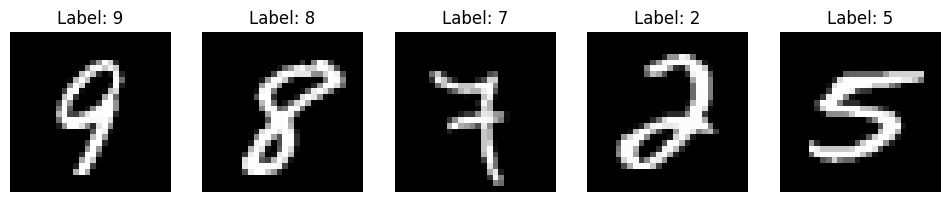

In [3]:
images, labels = next(iter(train_loader))  # grabs one random batch of 64

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.show()

It appears that the first five labels of the dataset match the first five images. Re-ran about 5 times, the labels continue to show the correct number correlation.

3. Build and train a CNN classifier on the MNIST training set.

In [4]:
# Defining the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(self.dropout1(x), 2)
        x = torch.flatten(x, 1)
        x = nn.functional.relu(self.fc1(self.dropout2(x)))
        x = self.fc2(x)
        return nn.functional.log_softmax(x, dim=1)


This CNN takes a 28×28 grayscale image and passes it through two
  convolutional layers (conv1, conv2) that learn increasingly complex
  visual features like edges and shapes. 
  
  Max pooling then halves the
  spatial dimensions from 28×28 to 14×14, reducing computation and
  building in some position-invariance. The result is flattened into a
  12,544-element vector (64 channels × 14 × 14) and fed through two
  fully connected layers that map those features down to 10 class
  scores. 
  
  Dropout is applied after both the conv layers (25%) and the
  first dense layer (50%) to prevent overfitting by randomly disabling
  neurons during training. Finally, log_softmax converts the raw scores
  into log-probabilities, where the index of the highest value is the
  predicted digit.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
# Initalize the model and optimizer
model = Net().to(device)
optimizer = optim.Adam(model.parameters())

In [7]:
# The model must now be compiled
model = torch.compile(model)

Defining the training loop, it starts with model.train(). This switches the model into training mode, which activates dropout. Without it, dropout would be disabled and the model would behave as if it were being evaluated.

In [8]:
# Set model to training mode (enables dropout)
model.train()

for batch_idx, (data, target) in enumerate(train_loader):
    # Move data and labels to the selected device (CPU or GPU)
    data, target = data.to(device), target.to(device)

    # Clear gradients from the previous step
    optimizer.zero_grad()

    # Forward pass: compute predictions
    output = model(data)

    # Compute the negative log-likelihood loss
    loss = nn.functional.nll_loss(output, target)

    # Backward pass: compute gradients
    loss.backward()

    # Update model weights
    optimizer.step()

The for loop iterates over every batch in train_loader. For each batch:                                                      
                                                                                                                             
  1. Move to device: sends the data and labels to CPU or GPU                                                                  
  2. Zero gradients: clears leftover gradients from the previous batch (PyTorch accumulates them by default)                  
  3. Forward pass: runs the batch through the network to get predictions                                                      
  4. Compute loss: measures how wrong the predictions are using NLL loss                                                      
  5. Backward pass: computes gradients via backpropagation                                                                    
  6. Update weights: Adam optimizer adjusts the model's weights to reduce the loss                                            
                                                                                                                               
  Then it repeats for the next batch until all 60,000 training images have been seen once.   

With the model trained, we now evaluate it on the test set. The testing loop runs the model over all 10,000 test images without updating any weights. We're only measuring performance. `model.eval()` disables dropout, and `torch.no_grad()` turns off gradient tracking to save memory and speed things up.

In [9]:
# Define the testing loop
model.eval()
test_loss = 0
correct = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)

        # Sum up batch loss
        test_loss += nn.functional.nll_loss(output, target, reduction='sum').item()

        # Get the index of the max log-probability
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

test_loss /= len(test_loader.dataset)

4. Report the test accuracy of your model.

In [10]:
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100. * correct / len(test_loader.dataset):.2f}%")

Test Loss: 0.0519
Test Accuracy: 98.30%


5. Display a confusion matrix on the test set classifications.

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_preds = []
all_targets = []

# Collect all predictions and true labels from the test set
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

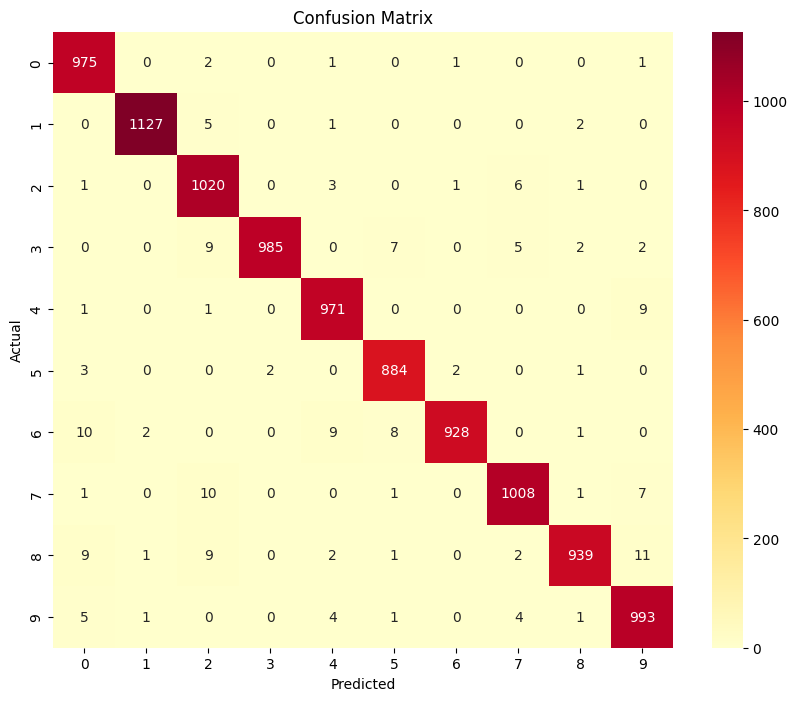

In [12]:
# Build and plot the confusion matrix
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Looking at this matrix, the model seems to have made the most mistakes on digits that look alike. For example, digit number 9 has the most misclassifications at <b>11</b>. There were also 11 sixes predicted as zero which makes visual sense because this misatke could have easily been made at an eye exam by a human.

#### 6. Summarize Your Results

In this notebook, a CNN classifier was built to identify handwritten digits from the MNIST dataset. The MNIST data was loaded using `torchvision.datasets.MNIST` and fed through the pipeline via PyTorch DataLoaders. Images were converted to normalized tensors and passed through a convolutional neural network (CNN) for classification. The model performed well with a test loss of 0.0524, meaning the predicted probabilities are close to the correct labels across the board. The model correctly classified 9,829 out of 10,000 test images after training on just a single epoch. This is strong performance for a single pass through the data and multiple epochs would likely push it higher. When visualizing the results through a confusion matrix, it was clear that visually similar digits such as "0" and "6", "7" and "9", and "5" and "3" showed the highest number of misclassifications.

This model performs well at generalizing unseen data. At 5%, the gap between training and test performance is small. That could be the result of the dropout regularization to prevent overfitting.